In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
df=df.dropna()
df['sex']=df['sex'].replace('.','MALE')

### Train | Test Split

In [4]:
X=pd.get_dummies(df.drop('species',axis=1),drop_first=True)

In [5]:
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True


In [6]:
y=df['species']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.3, random_state=101)

### Random forest classification

In [9]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
model= RandomForestClassifier(n_estimators=10,max_features='sqrt',random_state=101)

In [11]:
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=101)

In [12]:
y_pred=model.predict(X_test)

### Model Evaluation

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [14]:
confusion_matrix(y_test,y_pred)

array([[40,  1,  0],
       [ 1, 22,  0],
       [ 0,  0, 37]])

In [15]:
model.feature_importances_

array([3.46584088e-01, 1.20150588e-01, 2.39262547e-01, 1.48533620e-01,
       1.39253740e-01, 2.10550136e-05, 6.19436222e-03])

### Choosing correct no. of trees

In [21]:
test_error=[]
misclassifications=[]
for n in range(1,40):
    model= RandomForestClassifier(n_estimators=n,max_features='sqrt')
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    n_missed= np.sum(pred!=y_test)
    misclassifications.append(n_missed)
    test_error.append(1-accuracy_score(pred, y_test))

In [22]:
test_error

[0.12871287128712872,
 0.06930693069306926,
 0.03960396039603964,
 0.00990099009900991,
 0.01980198019801982,
 0.02970297029702973,
 0.01980198019801982,
 0.02970297029702973,
 0.01980198019801982,
 0.02970297029702973,
 0.00990099009900991,
 0.00990099009900991,
 0.01980198019801982,
 0.00990099009900991,
 0.02970297029702973,
 0.01980198019801982,
 0.00990099009900991,
 0.01980198019801982,
 0.01980198019801982,
 0.00990099009900991,
 0.01980198019801982,
 0.00990099009900991,
 0.00990099009900991,
 0.00990099009900991,
 0.00990099009900991,
 0.01980198019801982,
 0.00990099009900991,
 0.00990099009900991,
 0.00990099009900991,
 0.00990099009900991,
 0.01980198019801982,
 0.01980198019801982,
 0.00990099009900991,
 0.00990099009900991,
 0.00990099009900991,
 0.01980198019801982,
 0.00990099009900991,
 0.00990099009900991,
 0.01980198019801982]

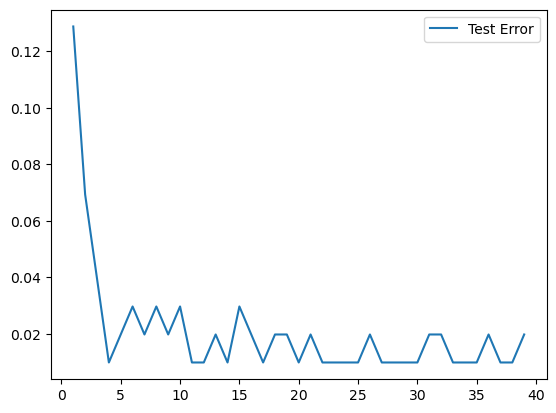

In [23]:
plt.plot(range(1,40), test_error,label='Test Error')
plt.legend()
plt.show()

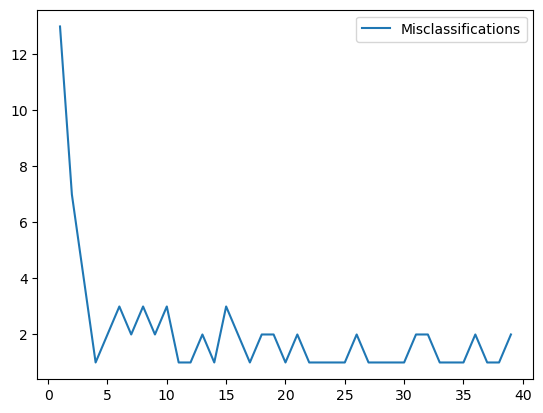

In [24]:
plt.plot(range(1,40), misclassifications,label='Misclassifications')
plt.legend()
plt.show()